## Name : Rishil Pawar

## Roll No. : C1-18

## NLP Lab-8

In [1]:
!pip install nltk gradio scikit-learn pandas matplotlib seaborn -q

In [2]:
import pandas as pd
import numpy as np
import nltk
import re
import warnings
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

print("All libraries imported successfully.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All libraries imported successfully.


In [9]:
df = pd.read_csv('/content/IMDB Dataset.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 3 rows:")
print(df.head(3))
print("\nClass Distribution:")
print(df['sentiment'].value_counts())
print("\nMissing Values:", df.isnull().sum().sum())

Dataset Shape: (50000, 2)

First 3 rows:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive

Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Missing Values: 0


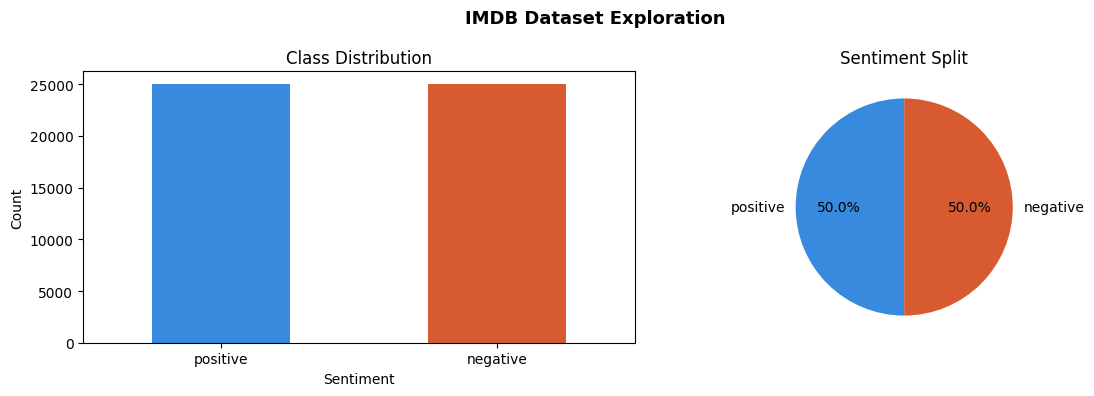

Screenshot saved: class_distribution.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['sentiment'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#378ADD', '#D85A30'], edgecolor='none'
)
axes[0].set_title('Class Distribution', fontsize=12)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['sentiment'].value_counts().plot(
    kind='pie', ax=axes[1],
    colors=['#378ADD', '#D85A30'],
    autopct='%1.1f%%', startangle=90
)
axes[1].set_title('Sentiment Split', fontsize=12)
axes[1].set_ylabel('')

plt.suptitle('IMDB Dataset Exploration', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Screenshot saved: class_distribution.png")

In [11]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    """Clean and normalise a review string."""
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [
        stemmer.stem(w)
        for w in tokens
        if w not in stop_words and len(w) > 2
    ]
    return ' '.join(tokens)

print("Preprocessing reviews... (this may take ~60 seconds)")
df['clean_review'] = df['review'].apply(preprocess)

df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print("\nPreprocessing complete!")
print(f"Total reviews processed: {len(df)}")

Preprocessing reviews... (this may take ~60 seconds)

Preprocessing complete!
Total reviews processed: 50000


In [25]:
idx = 0
print("=============================================")
print("BEFORE PREPROCESSING:")
print("=============================================")
print(df['review'].iloc[idx][:400])

print("\n" + "============================================")
print("AFTER PREPROCESSING:")
print("=============================================")
print(df['clean_review'].iloc[idx][:400])

print("\nSample data with labels:")
print(df[['clean_review', 'label']].head(5))

BEFORE PREPROCESSING:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to

AFTER PREPROCESSING:
one review mention watch episod youll hook right exactli happen meth first thing struck brutal unflinch scene violenc set right word trust show faint heart timid show pull punch regard drug sex violenc hardcor classic use wordit call nicknam given oswald maximum secur state penitentari focus mainli emerald citi experiment section prison cell glass front face inward privaci high agenda citi home ma

Sample data with labels:
                                        clean_review  label
0  one review mention watch episod youll hook rig...      1
1  wonde

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X = df['clean_review']
y = df['label']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

X_train = tfidf.fit_transform(X_train_raw)
X_test  = tfidf.transform(X_test_raw)

print(f"Training set size : {X_train.shape}")
print(f"Test set size     : {X_test.shape}")
print(f"Vocabulary size   : {len(tfidf.vocabulary_)}")
print("\nTop 20 TF-IDF features:")
print(tfidf.get_feature_names_out()[:20])

Training set size : (40000, 10000)
Test set size     : (10000, 10000)
Vocabulary size   : 10000

Top 20 TF-IDF features:
['aaron' 'abandon' 'abbott' 'abc' 'abduct' 'abil' 'abl' 'abl get'
 'abl make' 'abl see' 'aboard' 'abomin' 'aborigin' 'abort' 'abound'
 'abraham' 'abroad' 'abrupt' 'abruptli' 'absenc']


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import time

models = {
    "Logistic Regression":     LogisticRegression(max_iter=1000, C=1.0),
    "Multinomial Naive Bayes": MultinomialNB(alpha=0.1),
    "Linear SVM":              LinearSVC(max_iter=2000, C=1.0),
    "Random Forest":           RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting":       GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = []

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    preds   = model.predict(X_test)
    elapsed = round(time.time() - t0, 2)

    acc  = round(accuracy_score(y_test, preds) * 100, 2)
    prec = round(precision_score(y_test, preds) * 100, 2)
    rec  = round(recall_score(y_test, preds) * 100, 2)
    f1   = round(f1_score(y_test, preds) * 100, 2)

    results.append({
        "Model": name,
        "Accuracy %":  acc,
        "Precision %": prec,
        "Recall %":    rec,
        "F1-Score %":  f1,
        "Time (s)":    elapsed
    })
    print(f"✓  {name:<30s}  Acc={acc}%   F1={f1}%   ({elapsed}s)")

results_df = pd.DataFrame(results).sort_values("Accuracy %", ascending=False).reset_index(drop=True)
print("\nAll models trained successfully.")

✓  Logistic Regression             Acc=89.05%   F1=89.14%   (1.27s)
✓  Multinomial Naive Bayes         Acc=86.35%   F1=86.61%   (0.08s)
✓  Linear SVM                      Acc=88.77%   F1=88.86%   (3.36s)
✓  Random Forest                   Acc=85.0%   F1=84.95%   (126.87s)
✓  Gradient Boosting               Acc=81.27%   F1=82.22%   (164.44s)

All models trained successfully.


In [26]:
print("====================================================")
print("MODEL COMPARISON TABLE")
print("====================================================")
print(results_df.to_string(index=False))
print("====================================================")

MODEL COMPARISON TABLE
                  Model  Accuracy %  Precision %  Recall %  F1-Score %  Time (s)
    Logistic Regression       89.05        88.43     89.86       89.14      1.27
             Linear SVM       88.77        88.17     89.56       88.86      3.36
Multinomial Naive Bayes       86.35        85.00     88.28       86.61      0.08
          Random Forest       85.00        85.21     84.70       84.95    126.87
      Gradient Boosting       81.27        78.25     86.62       82.22    164.44


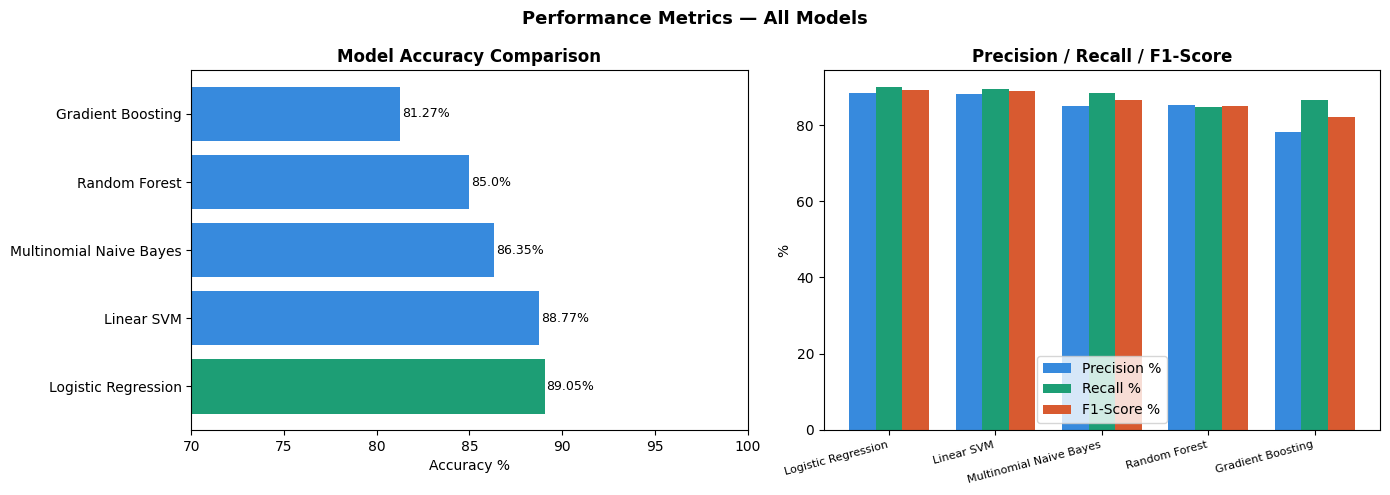

Screenshot saved: metrics_comparison.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].barh(
    results_df["Model"],
    results_df["Accuracy %"],
    color=['#1D9E75' if i == 0 else '#378ADD' for i in range(len(results_df))],
    edgecolor='none'
)
axes[0].set_xlabel("Accuracy %")
axes[0].set_title("Model Accuracy Comparison", fontweight='bold')
axes[0].set_xlim([70, 100])
for i, v in enumerate(results_df["Accuracy %"]):
    axes[0].text(v + 0.1, i, f"{v}%", va='center', fontsize=9)

metrics  = ["Precision %", "Recall %", "F1-Score %"]
x        = np.arange(len(results_df))
width    = 0.25
colors   = ['#378ADD', '#1D9E75', '#D85A30']
for i, (m, c) in enumerate(zip(metrics, colors)):
    axes[1].bar(x + i * width, results_df[m], width, label=m, color=c, edgecolor='none')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(results_df["Model"], rotation=15, ha='right', fontsize=8)
axes[1].set_ylabel("%")
axes[1].set_title("Precision / Recall / F1-Score", fontweight='bold')
axes[1].legend()

plt.suptitle("Performance Metrics — All Models", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Screenshot saved: metrics_comparison.png")

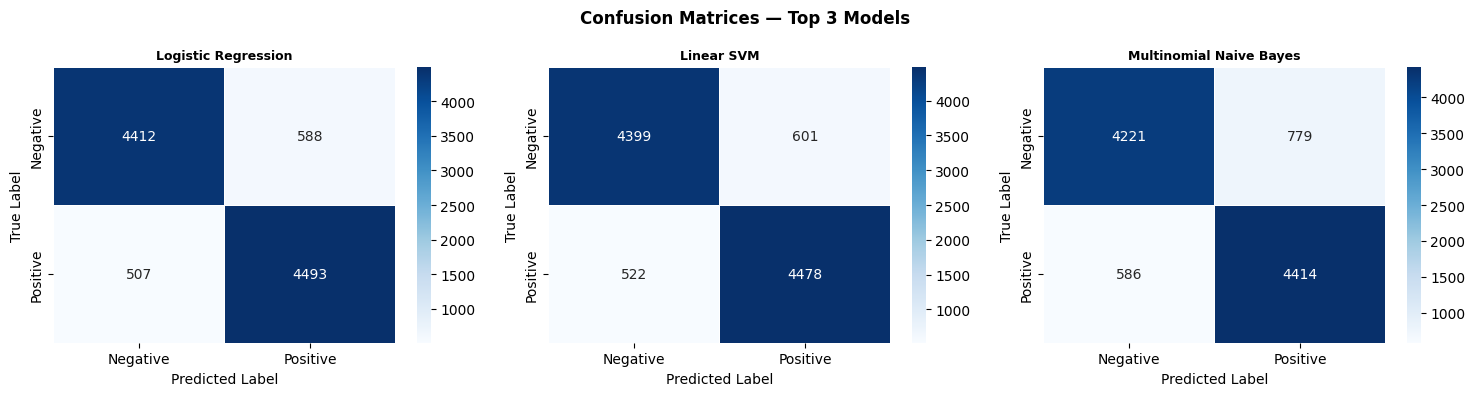

Screenshot saved: confusion_matrices.png


In [17]:
top3_names = results_df["Model"].head(3).tolist()
fig, axes  = plt.subplots(1, 3, figsize=(15, 4))

for ax, name in zip(axes, top3_names):
    preds = models[name].predict(X_test)
    cm    = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        cmap='Blues', linewidths=0.5,
        xticklabels=['Negative', 'Positive'],
        yticklabels=['Negative', 'Positive']
    )
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.suptitle("Confusion Matrices — Top 3 Models", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Screenshot saved: confusion_matrices.png")

In [32]:
best_row   = results_df.iloc[0]
best_name  = best_row["Model"]
best_acc   = best_row["Accuracy %"]
best_model = models[best_name]

print("===========================================================")
print("BEST MODEL SELECTION")
print(("==========================================================="))
print(f"  Model     : {best_name}")
print(f"  Accuracy  : {best_acc}%")
print(f"  Precision : {best_row['Precision %']}%")
print(f"  Recall    : {best_row['Recall %']}%")
print(f"  F1-Score  : {best_row['F1-Score %']}%")
print(("==========================================================="))

best_preds = best_model.predict(X_test)
print("\nDetailed Classification Report:")
print(classification_report(y_test, best_preds,
      target_names=['Negative', 'Positive']))

BEST MODEL SELECTION
  Model     : Logistic Regression
  Accuracy  : 89.05%
  Precision : 88.43%
  Recall    : 89.86%
  F1-Score  : 89.14%

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      5000
    Positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [19]:
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Model saved     → best_model.pkl")
print("Vectorizer saved → tfidf_vectorizer.pkl")

with open('best_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
with open('tfidf_vectorizer.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)

test_pred = loaded_model.predict(loaded_tfidf.transform(["This movie was great!"]))
print(f"\nReload test — 'This movie was great!' → {'Positive' if test_pred[0]==1 else 'Negative'}")
print("Models loaded and verified successfully.")

Model saved     → best_model.pkl
Vectorizer saved → tfidf_vectorizer.pkl

Reload test — 'This movie was great!' → Positive
Models loaded and verified successfully.


In [29]:
import gradio as gr

def predict_sentiment(review: str) -> str:
    """Predict sentiment for a given movie review string."""
    if not review.strip():
        return "⚠  Please enter a review."

    cleaned = preprocess(review)
    vec     = tfidf.transform([cleaned])
    pred    = best_model.predict(vec)[0]

    try:
        prob     = best_model.predict_proba(vec)[0]
        conf     = round(max(prob) * 100, 1)
        conf_str = f"  (confidence: {conf}%)"
    except AttributeError:
        conf_str = ""

    label = "🟢  POSITIVE" if pred == 1 else "🔴  NEGATIVE"
    return f"{label}{conf_str}"


examples = [
    ["This movie was absolutely brilliant! A masterpiece of storytelling with superb acting."],
    ["Terrible film. Complete waste of time. The plot was dull and the acting was awful."],
    ["It was an average movie. Not great, not terrible. Some scenes were enjoyable."],
    ["One of the best films I have ever seen. Highly recommend it to everyone!"],
    ["I fell asleep halfway through. Boring script and poor direction."],
]

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=5,
        placeholder="Paste your movie review here...",
        label="Movie Review"
    ),
    outputs=gr.Textbox(label="Predicted Sentiment"),
    title="🎬 Movie Review Sentiment Analyser",
    description=(
        f"Classifies movie reviews as Positive or Negative.\n"
        f"Best Model: **{best_name}**  |  Test Accuracy: **{best_acc}%**\n"
        f"Trained on IMDB dataset (50,000 reviews)"
    ),
    examples=examples,
    theme=gr.themes.Soft(),
    allow_flagging="never"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2d0144f6c9632fdcb4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
